## 3. Category Prediction: Predict the category from a review.

### 1. Load Libraries

In [ ]:
import gzip
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### 2. Read Dataset

In [ ]:
def readGz(filename):
  f = gzip.open(filename, 'rb')
  for l in (f):
    yield eval(l)

In [ ]:
reviews = []
for l in readGz("train_json.gz"):
    reviews.append(l)
print('Total Number of Reviews: ' , (len(reviews)))

df_reviews = pd.DataFrame (reviews)
#df_reviews.head()

Total Number of Reviews:  200000


In [ ]:
df_reviews.head()

,reviewTime,reviewText,helpful,reviewerID,reviewHash,categories,unixReviewTime,itemID,rating,summary,categoryID,price
0,"09 26, 2013",The model in this picture has them rolled up a...,"{'nHelpful': 0, 'outOf': 0}",U490934656,R798569390,"[[Clothing, Shoes & Jewelry, Women], [Clothing...",1380153600,I402344648,4.0,High Waisted,0,NaN
1,"02 7, 2013","I love the look of this bra, it is what I want...","{'nHelpful': 0, 'outOf': 0}",U714157797,R436443063,"[[Clothing, Shoes & Jewelry, Women, Clothing, ...",1360195200,I697650540,4.0,Beautiful but size runs small,0,NaN
2,"03 16, 2014",I am not comfortable with wearing my wedding b...,"{'nHelpful': 0, 'outOf': 0}",U507366950,R103439446,"[[Clothing, Shoes & Jewelry, Wedding Party Gif...",1394928000,I464613034,5.0,Great Alternative for Nurses,0,19.99
3,"03 10, 2014",Like the look of this top and really looks cut...,"{'nHelpful': 0, 'outOf': 0}",U307862152,R486351639,"[[Clothing, Shoes & Jewelry, Women, Clothing, ...",1394409600,I559560885,2.0,One size fits all...Questionable,0,18.99
4,"07 30, 2013",I'm quite small and the XS fits me like a regu...,"{'nHelpful': 1, 'outOf': 1}",U742726598,R508664275,"[[Clothing, Shoes & Jewelry, Women, Plus-Size,...",1375142400,I476005312,5.0,Great shirt,0,NaN


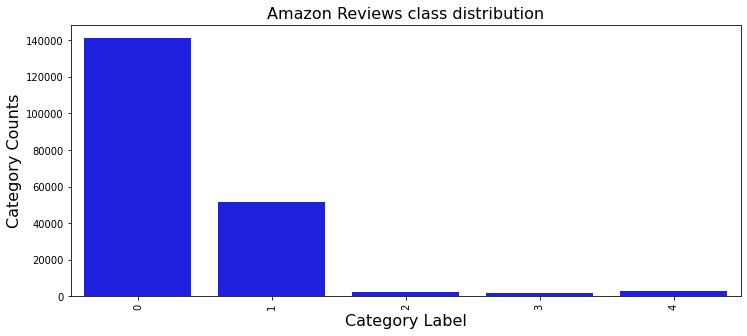

In [ ]:
%matplotlib inline

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.countplot(x=df_reviews.categoryID, color='blue')
plt.title('Amazon Reviews class distribution', fontsize=16)
plt.ylabel('Category Counts', fontsize=16)
plt.xlabel('Category Label', fontsize=16)
plt.xticks(rotation='vertical');

### 3. Text Cleansing and Preprocessing Methods

In [ ]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
stoplist = stopwords.words('english') + list(string.punctuation)
stoplist = set(stoplist)

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/hemakadali/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
def text_preprocess(message):
    # Remove punctuations
    nopunc = [char for char in message if char not in string.punctuation]

    # Join the characters again
    nopunc = "".join(nopunc)
    nopunc = nopunc.lower()

    # Remove any stopwords and non-alphabetic characters
    nostop = [
        word
        for word in nopunc.split()
        if word.lower() not in stopwords.words("english") and word.isalpha()
    ]
    non_stop_string = string = " "
    return (non_stop_string.join(nonstop)) 


def preprocess(text):
    ps = nltk.PorterStemmer()
    #w = [ps.stem(word) for word in words_new]
    non_stop_string = string = " "
    
    stop_words_text = [word for word in word_tokenize(text) 
                                 if word.lower() not in stoplist and not word.isdigit()]
    stem_stop_words_text = [ps.stem(word) for word in word_tokenize(text)]
    
    #return non_stop_string.join([word for word in word_tokenize(text) 
    #                             if word.lower() not in stoplist and not word.isdigit()])
    #return non_stop_string.join(stem_stop_words_text)
    return non_stop_string.join(stop_words_text)


    

In [ ]:
from gensim import utils
import gensim.parsing.preprocessing as gsp

filters = [
           gsp.strip_tags, 
           gsp.strip_punctuation,
           gsp.strip_multiple_whitespaces,
           gsp.strip_numeric,
           gsp.remove_stopwords, 
           gsp.strip_short, 
           gsp.stem_text
          ]

def clean_text(s):
    s = s.lower()
    s = utils.to_unicode(s)
    for f in filters:
        s = f(s)
    return s

### 4. Create Word Clouds for each category

In [ ]:
%matplotlib inline

from wordcloud import WordCloud

def plot_word_cloud(text):
    wordcloud_instance = WordCloud(width = 800, height = 800, 
                background_color ='black', 
                stopwords=None,
                min_font_size = 10).generate(text) 
             
    plt.figure(figsize = (8, 8), facecolor = None) 
    plt.imshow(wordcloud_instance) 
    plt.axis("off") 
    plt.tight_layout(pad = 0) 
    plt.show()

In [ ]:
#preprocess data
#df_reviews["reviewText"] = df_reviews["reviewText"].apply(clean_text)
#df_reviews.head()

In [ ]:
def plot_word_cloud_for_category(df_reviews, categoryID):
    text_df = df_reviews.loc[df_reviews['categoryID'] == categoryID]
    texts = ''
    for index, item in text_df.iterrows():
        texts = texts + ' ' + item['reviewText']
    
    plot_word_cloud(texts)

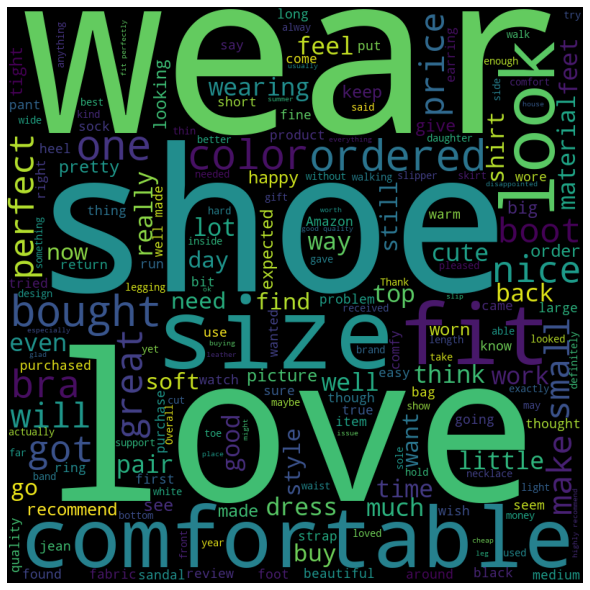

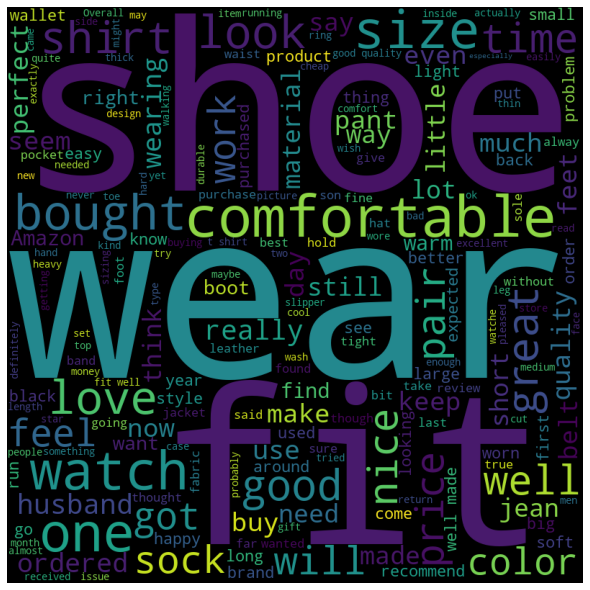

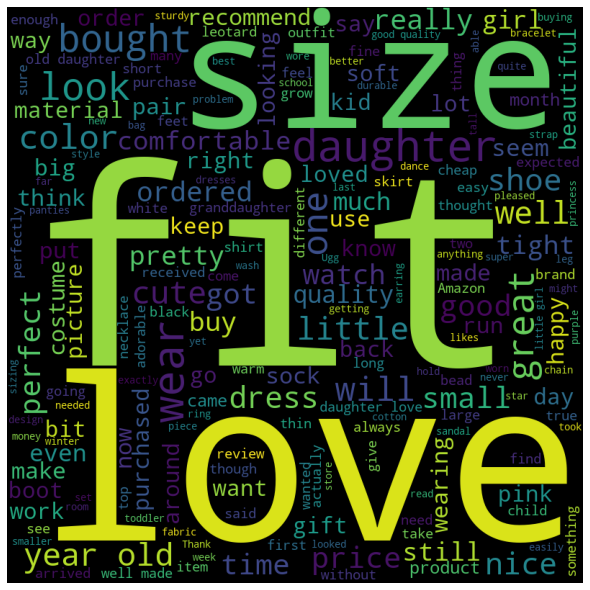

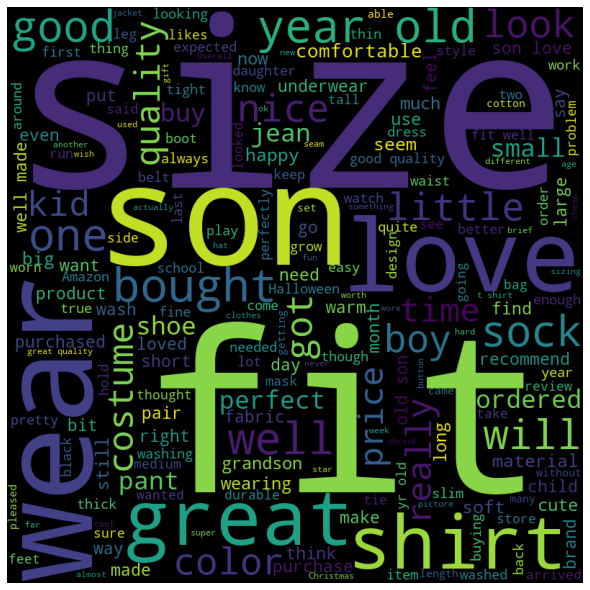

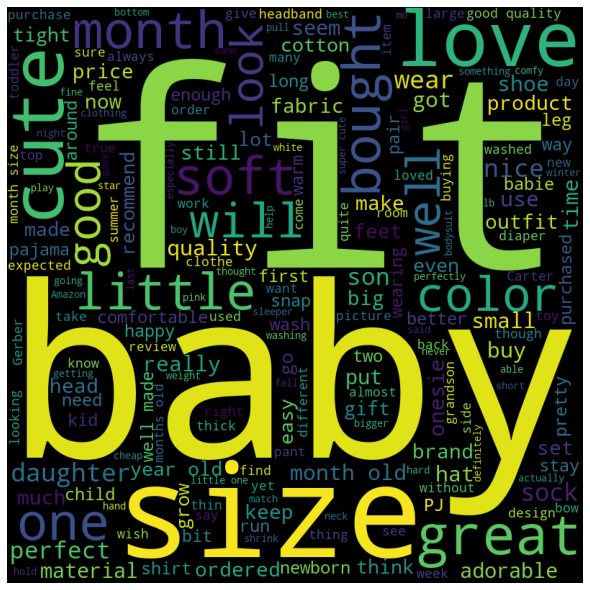

In [ ]:
plot_word_cloud_for_category(df_reviews,0)
plot_word_cloud_for_category(df_reviews,1)
plot_word_cloud_for_category(df_reviews,2)
plot_word_cloud_for_category(df_reviews,3)
plot_word_cloud_for_category(df_reviews,4)

In [ ]:
df_reviews['categoryID'].value_counts()

0    141398
1     51416
4      2976
2      2329
3      1881
Name: categoryID, dtype: int64

### 5. Prepare Dataset

In [ ]:
df_x = df_reviews['reviewText']
df_y = df_reviews['categoryID']


In [ ]:
#Tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import BaseEstimator

class Text2TfIdfTransformer(BaseEstimator):

    def __init__(self):
        self._model = TfidfVectorizer()
        pass
    
    def fit(self, df_x, df_y=None):
        self._model.fit(df_x)
        return self

    def transform(self, df_x):
        return self._model.transform(df_x)


### 5.1 Vectorize the recview text words

In [ ]:
tfidf_transformer = Text2TfIdfTransformer()
tfidf_vectors = tfidf_transformer.fit(df_x).transform(df_x)

In [ ]:
tfidf_vectors.shape

(200000, 63971)

In [ ]:
 print(df_x.shape, df_y.shape)

(200000,) (200000,)


In [ ]:
# Split the dataset to train and test sets


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.01)

### 6 Run Different Models and Compare them

In [ ]:
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
benchmark = {}
# Iterate over all algorithms - LR, XGboost', 'svm', Naive Bayes'
for algorithm in ['LR','XG']:  
    if algorithm == 'LR':
        model_tf_idf = Pipeline(steps=[('tfidf',Text2TfIdfTransformer()),
                ('log_reg', LogisticRegression(C=2.9,multi_class='multinomial', solver='sag', max_iter=300))])
    
    if algorithm == 'XG':
        model_tf_idf = Pipeline(steps=[('tfidf',Text2TfIdfTransformer()),
                        ('xgboost', xgb.XGBClassifier(max_depth = 5,subsample=1,objective='multi:softmax'))])  
        

    # Get results & append 
    scores = cross_val_score(model_tf_idf , df_x, df_y, cv=5,scoring='accuracy')
    benchmark[algorithm] = scores.mean()
    
  
print(benchmark)

{'LR': 0.84831, 'XG': 0.8161400000000001}


In [ ]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
for algorithm in ['NB','SVC']:  
    if algorithm == 'SVC':
        model_tf_idf = Pipeline(steps=[('tfidf',Text2TfIdfTransformer()),
                           ('svc', SVC(C=1.0, class_weight=None))])
    
    if algorithm == 'NB':
        model_tf_idf = Pipeline(steps=[('tfidf',Text2TfIdfTransformer()),
                        ('clf', MultinomialNB())])  

    # Get results & append 
    scores = cross_val_score(model_tf_idf , df_x, df_y, cv=5,scoring='accuracy')
    benchmark[algorithm] = scores.mean()
    

In [ ]:
print(benchmark)

{'LR': 0.84831, 'XG': 0.8161400000000001, 'NB': 0.770895, 'SVC': 0.848325}


In [ ]:
# select the best model

model_tf_idf = Pipeline(steps=[('tfidf',Text2TfIdfTransformer()),
                ('log_reg', LogisticRegression(C=1.7,multi_class='multinomial', solver='sag', max_iter=300))])

In [ ]:
#model_tf_idf.fit(X_train, y_train)
model_tf_idf.fit(df_x, df_y)

Pipeline(steps=[('tfidf', Text2TfIdfTransformer()),
                ('log_reg',
                 LogisticRegression(C=1.7, max_iter=300,
                                    multi_class='multinomial', solver='sag'))])

In [ ]:
from sklearn import metrics
y_pred = model_tf_idf.predict(X_test)
# Print the overall accuracy
print(metrics.accuracy_score(y_test,y_pred))

0.878


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92      1407
           1       0.84      0.75      0.79       520
           2       0.75      0.10      0.18        29
           3       0.62      0.42      0.50        12
           4       0.86      0.59      0.70        32

    accuracy                           0.88      2000
   macro avg       0.79      0.56      0.62      2000
weighted avg       0.87      0.88      0.87      2000

[[1337   69    0    0    1]
 [ 125  392    1    2    0]
 [  21    3    3    0    2]
 [   3    4    0    5    0]
 [  11    1    0    1   19]]


In [ ]:
reviews_test = []
for l in readGz("test_Category_json.gz"):
    reviews_test.append(l)
print('Total Number of Reviews: ' , (len(reviews)))

df_reviews_test = pd.DataFrame (reviews_test)
df_reviews_test.head()

Total Number of Reviews:  200000


,reviewTime,reviewText,helpful,reviewerID,reviewHash,unixReviewTime,rating,summary,price
0,"07 26, 2013","I love this blouse, in fact I have it on right...","{'nHelpful': 9, 'outOf': 9}",U281659737,R934811302,1374796800,5.0,love it,NaN
1,"06 8, 2014",Cute product. Loved the fit. Fast shipping! I ...,"{'nHelpful': 0, 'outOf': 0}",U670561057,R657711680,1402185600,4.0,Cute but a bit uncomfortable,NaN
2,"03 21, 2012",I wanted a formal watch that had a big face an...,"{'nHelpful': 0, 'outOf': 0}",U433746872,R750304163,1332288000,5.0,"Bold, Large-face Watch",NaN
3,"06 27, 2014",My daughter used this dress for her first comm...,"{'nHelpful': 0, 'outOf': 0}",U327816997,R865011815,1403827200,5.0,The perfect Dress,NaN
4,"03 21, 2014","Nice shirt, good quality with pockets. Kind o...","{'nHelpful': 1, 'outOf': 1}",U323131234,R222729968,1395360000,5.0,Nice shirt,NaN


In [ ]:
#df_reviews_test["reviewText"] = df_reviews_test["reviewText"].apply(preprocess)
#df_reviews_test['reviewText'] = df_reviews_test['reviewText'].apply(lambda x: " ".join([stemmer.stem(i) for i in re.sub("[^a-zA-Z]", " ", x).split() if i not in words]).lower())

In [ ]:
df_x1 = df_reviews_test['reviewText']

In [ ]:
predictions_x = model_tf_idf.predict(df_x1)
print(len(predictions_x))

14000


In [ ]:
#predictions_x.shape

In [ ]:
#pred_t = predictions_x.T

In [ ]:
df_reviews_test['category'] = predictions_x
#df_reviews_test['prediction_1'] = pred_t[1]
#df_reviews_test['prediction_2'] = pred_t[2]
#df_reviews_test['prediction_3'] = pred_t[3]
#df_reviews_test['prediction_4'] = pred_t[4]

In [ ]:
df_reviews_test.head()

,reviewTime,reviewText,helpful,reviewerID,reviewHash,unixReviewTime,rating,summary,price,category
0,"07 26, 2013","I love this blouse, in fact I have it on right...","{'nHelpful': 9, 'outOf': 9}",U281659737,R934811302,1374796800,5.0,love it,NaN,0
1,"06 8, 2014",Cute product. Loved the fit. Fast shipping! I ...,"{'nHelpful': 0, 'outOf': 0}",U670561057,R657711680,1402185600,4.0,Cute but a bit uncomfortable,NaN,0
2,"03 21, 2012",I wanted a formal watch that had a big face an...,"{'nHelpful': 0, 'outOf': 0}",U433746872,R750304163,1332288000,5.0,"Bold, Large-face Watch",NaN,1
3,"06 27, 2014",My daughter used this dress for her first comm...,"{'nHelpful': 0, 'outOf': 0}",U327816997,R865011815,1403827200,5.0,The perfect Dress,NaN,0
4,"03 21, 2014","Nice shirt, good quality with pockets. Kind o...","{'nHelpful': 1, 'outOf': 1}",U323131234,R222729968,1395360000,5.0,Nice shirt,NaN,1


In [ ]:
df_reviews_test['reviewerID-reviewHash'] = df_reviews_test['reviewerID'] + "-" + df_reviews_test['reviewHash'] 
df2_category_final =  df_reviews_test[['reviewerID-reviewHash','category']].copy()
df2_category_final.to_csv('predictions_category_final.csv',index = False)